# Air Passengers Forecasting with Time Series Analysis

In this project, we study the time series related to the number of airline passengers between 1949 and 1960. To do this, we use the libraries pandas, NumPy, scikit-learn, Prophet, and statsmodels. We also use an auxiliary file (*graph.py*) to improve readability.

The workflow will be the following:

-) Loading libraries and data cleaning <br>
-) Exploratory data analysis and decomposition of the time series, statistical test on autocorrelation and stationarity<br>
-) Forecasting with seasonal naive forecast, Prophet and SARIMA<br>
-) Conclusions

## Loading libraries and file

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.stattools import pacf, adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from graph import graph
df = pd.read_csv("airline-passengers.csv")
df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


# Data cleaning

In the next passage we check if the data are clean, we will compute the mean, standard deviation and quartile.

In [2]:
df.isna().sum()

Month         0
Passengers    0
dtype: int64

In [3]:
df.describe()

,Passengers
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


Now we convert the format of the date to a suitable form using the function .to_datetime of Pandas. Furthermore we check duplicates as part of data cleaning.

In [4]:
parts = df["Month"].str.split("-", expand=True).astype(int)
df["Date"] = pd.to_datetime({"year": parts[0],"month": parts[1],"day": 1})
df["Date"].duplicated().sum() #check duplicate

np.int64(0)

## Exploratory data analysis

In this part of the project we analyze some graph in order to understand if there are trends or seasonality. In order to do it we use the function graph written in *graph.py*.

We will notice the presence of an ascending trend and a seasonality component.

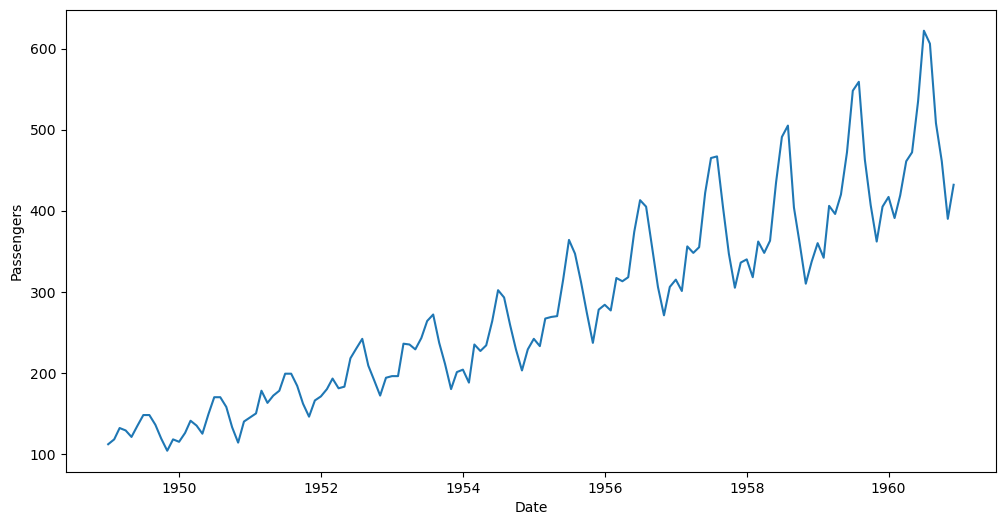

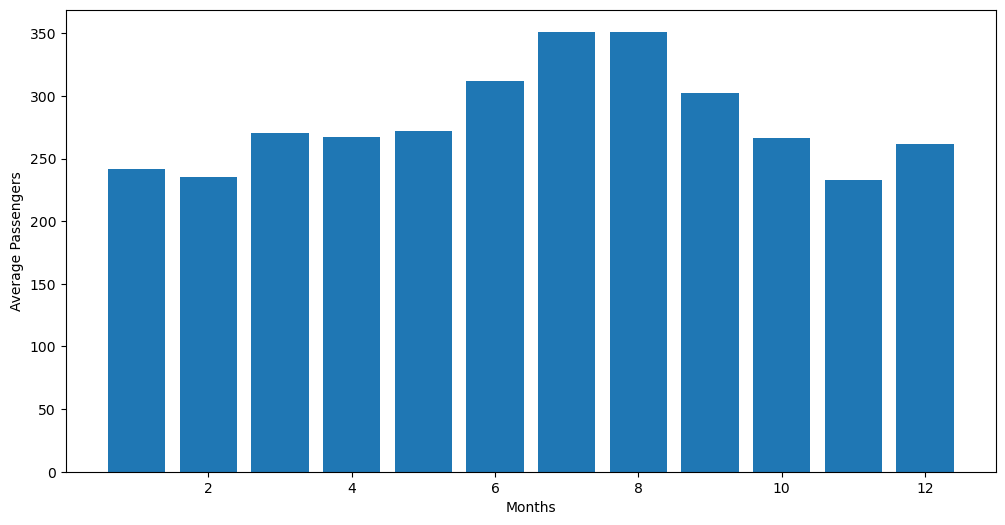

<Figure size 1200x600 with 0 Axes>

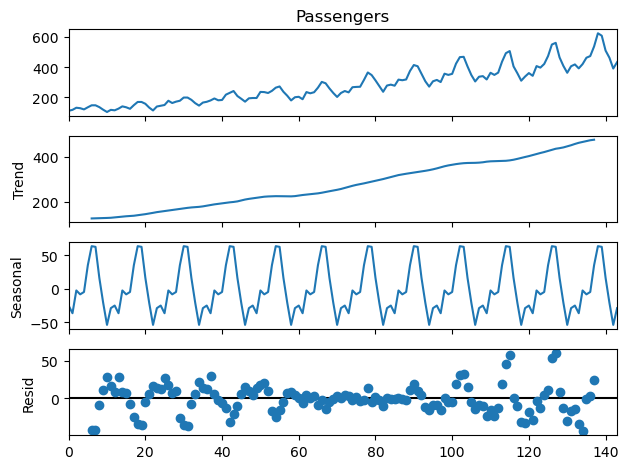

In [5]:
graph(df)

From the previous graphs we notice the presence of a trend and a seasonal part, hence we use the seasonal decomposition to focus better this part of the series. To confirm it we compute the graph of autocorrelation of the series until the 30th lag. Let us recall that
$$ Corr(X_i, X{i-k}) = \frac{Cov(X_i, X_{i-k})}{\sigma_{X_i} \sigma_{X_{i-k}}} $$

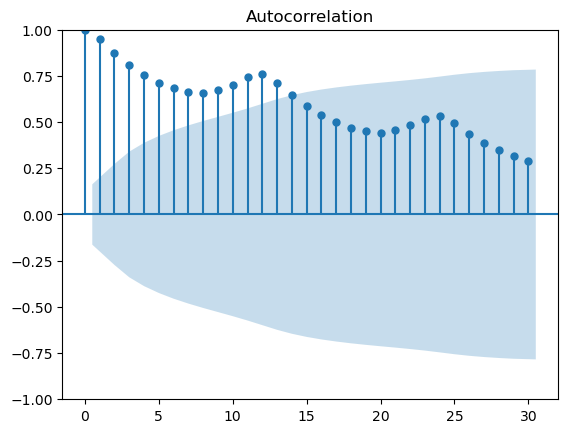

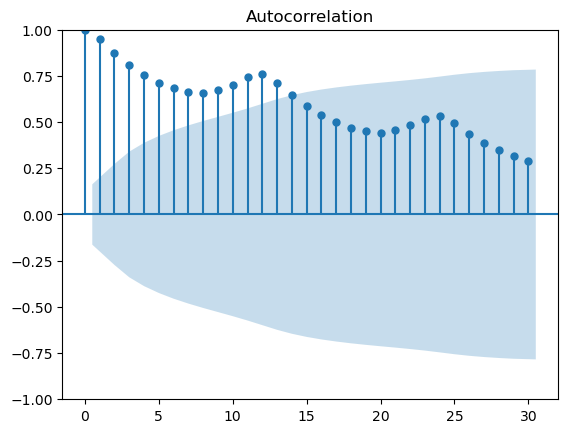

In [6]:
plot_acf(df["Passengers"].dropna(), lags=30)

We note that there are some spikes on 12th and 24th values which suggest the presence of seasonality. We study now the Partial Autocorrelation Function.

The **Partial Autocorrelation Function** shows the relationship between a time series and its past values, after removing the effect of the values in between. For example, suppose we compare today’s value with the value from 3 days ago. Then PACF removes the effect of yesterday
and 2 days ago. We study now it until the 30th lag.

In [7]:
pacf_values = pacf(df["Passengers"].dropna(), nlags=30, method="ywm")
print(pacf_values)

[ 1.          0.94804734 -0.22942187  0.03814778  0.09378544  0.0736067
  0.0077276   0.12559713  0.08995134  0.23248854  0.16605126  0.17127442
 -0.1354311  -0.53969124 -0.02661014  0.09076498  0.02495556  0.03251557
  0.07343264  0.04844211 -0.04554168  0.04575294 -0.10017888  0.05243494
  0.04801413 -0.16274616 -0.03613503  0.06642377  0.00617612  0.00753714
  0.01935049]


We ignore the value in 0. Then we notice that in the first lag we have the value 0.94804734, which suggest the use of a model with AR(1) with seasonality. We compute now the Augmented Dickey-Fuller test to stationarity of the time series.

A time series $ y_t $ is **stationary** if its statistical properties are constant over time i.e. $E[y_t] = \mu$, $Var(y_t) = \sigma^2$, $Cov(y_t, y_{t-k}) = \gamma_k$. 
The **Augmented Dickey-Fuller (ADF) test** checks if a time series has a unit root, which would imply non-stationarity.
The ADF regression is:

$$
\Delta y_t = \alpha + \beta t + \gamma y_{t-1} + \sum_{i=1}^{p} \delta_i \Delta y_{t-i} + \varepsilon_t
$$

where $\Delta y_t = y_t - y_{t-1}$

The hypotheses are: $H_0: \gamma = 0$ and $H_1: \gamma < 0$. If it holds $H_0$ then it is non-stationary, if not yes.

In [8]:
def ADF(ser):
    result = adfuller(ser)
    print("ADF statistic:", result[0])
    print("p-value:", result[1])
    if result[1]>0.05:
        print("Fail to reject the null hypothesis of a unit root: not stationary")
    else:
        print("Fail to accept the null hypothesis of a unit root: stationary")

ADF(df["Passengers"])

ADF statistic: 0.8153688792060472
p-value: 0.991880243437641
Fail to reject the null hypothesis of a unit root: not stationary


The series is not stationary. Hence we have to differentiate the series.

**Differencing** is a transformation used to make a non-stationary time series more stationary by removing trends. As example the first difference is:

$$ \Delta y_t = y_t - y_{t-1} $$

And in a similar way we may differentiate for further orders.

In [9]:
df["Passengers_diff"] = df["Passengers"].diff()
ADF(df["Passengers_diff"].dropna())

ADF statistic: -2.8292668241699905
p-value: 0.05421329028382671
Fail to reject the null hypothesis of a unit root: not stationary


In [10]:
df["Passengers_diff2"] = df["Passengers_diff"].diff()
ADF(df["Passengers_diff2"].dropna())

ADF statistic: -16.384231542468463
p-value: 2.732891850014476e-29
Fail to accept the null hypothesis of a unit root: stationary


## Forecast

In this section we try to find predict the model associated to the time series. We define some metrics in order to evaluate our models.

We now define a function with the metric for evaluate a model. The **mean absolute error** measures the average absolute difference between the true values and the predicted values, i.e.
$$
MAE = \frac{1}{n}\sum_{i=1}^{n} |y_i - \hat{y}_i|
$$

where $y_i$  is true value, $\hat{y}_i$ is predicted value and $n$ is number of observations. Lower MAE implies better predictions, even though it is sensible to the presence of outliers; meanwhile the $R^2$ coefficient  measures how much of the variance in the target variable is explained by the model.

$$
R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}
$$

where $y_i$ is true value, $\hat{y}_i$ is predicted value and $\bar{y}$ is mean of true values. $R^2 = 1$ means perfect prediction, while $R^2 = 0$ means the model performs as the mean value. A negative value means that the model performs badly or it is necessary feature engineering.

In [11]:
def regression_metrics(y_true, y_pred):
    return {"mae": mean_absolute_error(y_true, y_pred), "r2": r2_score(y_true, y_pred)}

We start with seasonal naive baseline, i.e. repeating for the last year the same trend of the previous year.

[467 404 347 305 336 340 318 362 348 363 435 491]
{'mae': 64.75862068965517, 'r2': 0.07279100624946888}


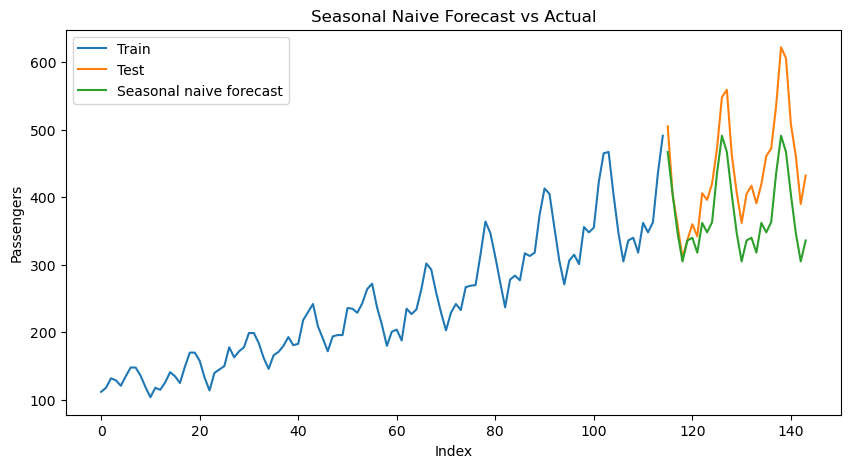

In [12]:
seasonal_period = 12
# test train
train_size = int(len(df) * 0.8)
train = df.iloc[:train_size]
test = df.iloc[train_size:]
last_season = train["Passengers"].iloc[-seasonal_period:].values
print(last_season)

# Repeat the last 12 months to cover the whole test horizon
n_test = len(test)
seasonal_naive_pred = np.tile(last_season,int(np.ceil(n_test / seasonal_period)))[:n_test]

actual = test["Passengers"].values

print(regression_metrics(actual, seasonal_naive_pred))

plt.figure(figsize=(10, 5))
plt.plot(train.index, train["Passengers"], label="Train")
plt.plot(test.index, test["Passengers"], label="Test")
plt.plot(test.index, seasonal_naive_pred, label="Seasonal naive forecast")
plt.legend()
plt.title("Seasonal Naive Forecast vs Actual")
plt.xlabel("Index")
plt.ylabel("Passengers")
plt.show()

**Prophet** is a forecasting model developed by Facebook for time series with **trend**, **seasonality** and considering the **holiday effects**.
We may write it as

$$
y(t) = g(t) + s(t) + h(t) + \varepsilon_t
$$

where: $g(t)$ is the trend $s(t)$ is the seasonal component $h(t)$ are holidays or special events $\varepsilon_t$ is the error term. 

We use the standard technique of machine learning: we split the set in 80% training part and 20% test part. Then we evaluate the model using mean absolute error and $R^2$ metric.

15:10:05 - cmdstanpy - INFO - Chain [1] start processing
15:10:05 - cmdstanpy - INFO - Chain [1] done processing


{'mae': 33.89631463022029, 'r2': 0.7201445663418973}


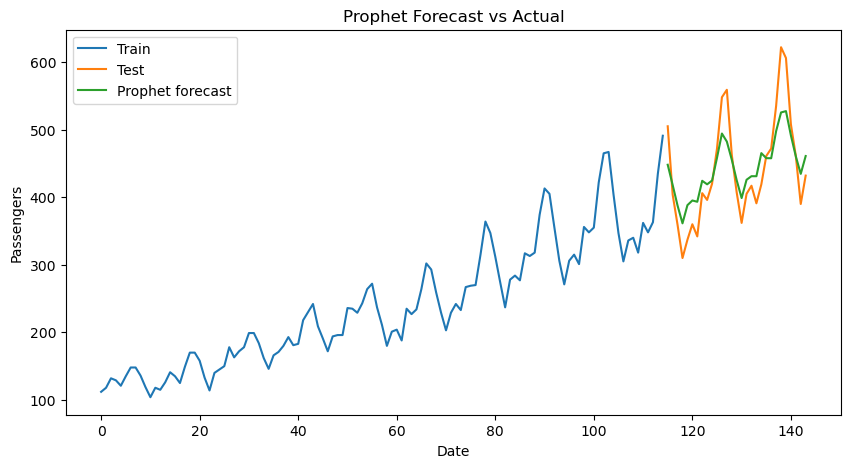

In [13]:
df_prophet = df[["Date", "Passengers"]].copy()

df_prophet = df_prophet.rename(columns={"Date": "ds", "Passengers": "y"}) #we need to rename the columns

df_prophet["ds"] = pd.to_datetime(df_prophet["ds"])
df_prophet = df_prophet.sort_values("ds").reset_index(drop=True)

train_size = int(len(df_prophet) * 0.8)

train_pro = df_prophet.iloc[:train_size]
test_pro = df_prophet.iloc[train_size:]

model = Prophet(yearly_seasonality=True, weekly_seasonality=False,daily_seasonality=False) #consider model with yearly seasonality

model.fit(train_pro)

# Predict exactly the dates in the test set
future_test = test_pro[["ds"]]

forecast_test = model.predict(future_test)

pred = forecast_test["yhat"].values
actual = test_pro["y"].values
print(regression_metrics(actual, pred)) #compute metrics
plt.figure(figsize=(10, 5)) #graph
plt.plot(train_pro.index, train_pro["y"], label="Train")
plt.plot(test_pro.index, test_pro["y"], label="Test")
plt.plot(test_pro.index, pred, label="Prophet forecast")
plt.legend()
plt.title("Prophet Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.show()

## SARIMA Forecasting

A SARIMA model is used to forecast monthly passenger values while accounting for both trend and yearly seasonality, taking in account the seasonality, autoregressive part and the moving avarage.
From the previous observation we may put AR(1) and I(2). Hence we try (1, 2, 1) with seasonal order (1, 1, 1, 12). 

{'mae': 28.17111949720956, 'r2': 0.8038281301477797}


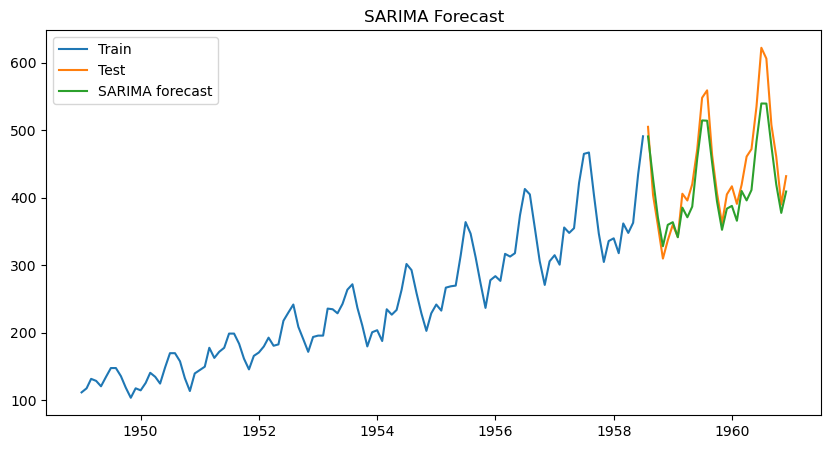

In [14]:
df_sarima = df[["Date", "Passengers"]].copy()
df_sarima["Date"] = pd.to_datetime(df_sarima["Date"])
df_sarima = df_sarima.set_index("Date") #our index are the dates
df_sarima = df_sarima.asfreq("MS")
train_size = int(len(df_sarima) * 0.8)
train_sa = df_sarima.iloc[:train_size]
test_sa = df_sarima.iloc[train_size:]
model = SARIMAX(train_sa["Passengers"],order=(1, 2, 1),seasonal_order=(1, 1, 1, 12),enforce_stationarity=False,enforce_invertibility=False)
model_fit = model.fit()
forecast_test = model_fit.forecast(steps=len(test_sa))
pred = forecast_test.values
actual = test_sa["Passengers"].values
print(regression_metrics(actual, pred))
plt.figure(figsize=(10, 5))
plt.plot(train_sa.index, train_sa["Passengers"], label="Train")
plt.plot(test_sa.index, test_sa["Passengers"], label="Test")
plt.plot(test_sa.index, pred, label="SARIMA forecast")
plt.legend()
plt.title("SARIMA Forecast")
plt.show()

## Conclusions and future steps

The dataset shows a clear upward trend and strong yearly seasonality. SARIMA performed best ($R^2$=0,8), outperforming Prophet ($R^2$=0,72) which is still better than the seasonal naive baseline ($R^2$=0,07). Future improvements could include residual diagnostics, cross-validation and hyperparameter tuning SARIMA.

### Business Interpretation

Forecasting can help airlines plan capacity, staffing, and pricing for high- and low-demand months.